# Figuras y cuadros del capítulo de Resultados

Todas las figuras salen de los CSV de `results/`, que a su vez vienen de las corridas en Kaggle o de los notebooks locales. Cada figura se guarda en `results/figuras/` a 200 ppp para insertarla en el documento.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
R = ROOT / "results"
FIG = R / "figuras"
FIG.mkdir(exist_ok=True)

AZUL, NARANJA, AQUA, AMARILLO = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
TINTA, TINTA_2, REJILLA = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10, "font.family": "serif",
    "axes.edgecolor": TINTA_2, "axes.labelcolor": TINTA, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": REJILLA,
    "grid.linewidth": 0.6, "axes.axisbelow": True, "legend.frameon": False,
})

def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(FIG / f"{nombre}.png", bbox_inches="tight", facecolor="white")

## Primer objetivo: selección del modelo

f1_onset         f1_note             ner          \
                           mean     std    mean     std    mean     std   
model                                                                     
Kong et al. (2021)       0.9589  0.0282  0.8374  0.0487  0.0801  0.0540   
hFT-Transformer (2023)   0.9668  0.0244  0.8930  0.0435  0.0636  0.0452   
Basic Pitch (2022)       0.6475  0.0821  0.1946  0.0671  0.6337  0.1148   

                       latency_norm          
                               mean     std  
model                                        
Kong et al. (2021)           0.0969  0.0027  
hFT-Transformer (2023)       0.0791  0.0083  
Basic Pitch (2022)           0.0302  0.0142

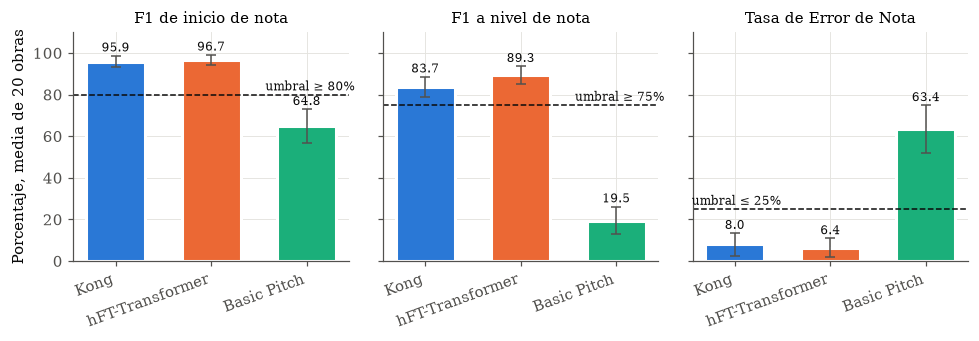

In [2]:
b = pd.read_csv(R / "oe1_benchmark_por_obra.csv")
orden = ["Kong et al. (2021)", "hFT-Transformer (2023)", "Basic Pitch (2022)"]
nombres = {"Kong et al. (2021)": "Kong", "hFT-Transformer (2023)": "hFT-Transformer", "Basic Pitch (2022)": "Basic Pitch"}
colores = [AZUL, NARANJA, AQUA]
metricas = [("f1_onset", "F1 de inicio de nota", 0.80, "≥"), ("f1_note", "F1 a nivel de nota", 0.75, "≥"), ("ner", "Tasa de Error de Nota", 0.25, "≤")]

fig, ejes = plt.subplots(1, 3, figsize=(9, 3.2), sharey=True)
for ax, (col, titulo, umbral, signo) in zip(ejes, metricas):
    g = b.groupby("model")[col].agg(["mean", "std"]).reindex(orden) * 100
    x = range(len(orden))
    ax.bar(x, g["mean"], yerr=g["std"], color=colores, width=0.62, edgecolor="white", linewidth=2, capsize=3, error_kw={"elinewidth": 1, "ecolor": TINTA_2})
    ax.axhline(umbral * 100, color=TINTA, linestyle="--", linewidth=1)
    izquierda = col == "ner"
    ax.text(-0.45 if izquierda else len(orden) - 0.5, umbral * 100 + 2, f"umbral {signo} {umbral:.0%}",
            ha="left" if izquierda else "right", fontsize=8, color=TINTA)
    for i, v in enumerate(g["mean"]):
        ax.text(i, v + g["std"].iloc[i] + 2, f"{v:.1f}", ha="center", fontsize=8, color=TINTA)
    ax.set_xticks(list(x), [nombres[m] for m in orden], rotation=20, ha="right")
    ax.set_title(titulo, fontsize=10)
    ax.set_ylim(0, 110)
ejes[0].set_ylabel("Porcentaje, media de 20 obras")
guardar(fig, "oe1_benchmark")
b.groupby("model")[["f1_onset", "f1_note", "ner", "latency_norm"]].agg(["mean", "std"]).reindex(orden).round(4)

## Segundo objetivo: robustez y ajuste fino

variant,ajustado,original,original_norm
condition,,,
limpio,82.81,83.81,83.77
mp3,82.30,82.21,82.23
ruido,76.81,75.24,75.09
reverb,68.66,62.58,62.57
celular,59.58,44.14,43.92
bajo,82.81,54.40,83.77


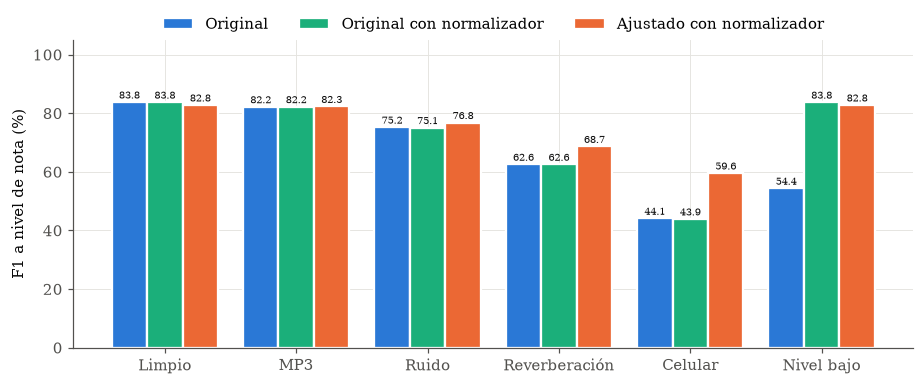

In [3]:
a = pd.read_csv(R / "oe2_ajuste_por_obra.csv")
condiciones = ["limpio", "mp3", "ruido", "reverb", "celular", "bajo"]
etiquetas = ["Limpio", "MP3", "Ruido", "Reverberación", "Celular", "Nivel bajo"]
p = a.pivot_table(index="condition", columns="variant", values="f1_note", aggfunc="mean").reindex(condiciones) * 100

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ancho = 0.27
xs = range(len(condiciones))
variantes = [("original", AZUL, "Original"), ("original_norm", AQUA, "Original con normalizador"), ("ajustado", NARANJA, "Ajustado con normalizador")]
for k, (var, color, nombre) in enumerate(variantes):
    pos = [x + (k - 1) * ancho for x in xs]
    ax.bar(pos, p[var], width=ancho, color=color, edgecolor="white", linewidth=1.5, label=nombre)
    for x, v in zip(pos, p[var]):
        ax.text(x, v + 1.2, f"{v:.1f}", ha="center", fontsize=6.5, color=TINTA)
ax.set_xticks(list(xs), etiquetas)
ax.set_ylabel("F1 a nivel de nota (%)")
ax.set_ylim(0, 105)
ax.legend(loc="upper center", ncols=3, bbox_to_anchor=(0.5, 1.12))
guardar(fig, "oe2_ajuste_por_condicion")
p.round(2)

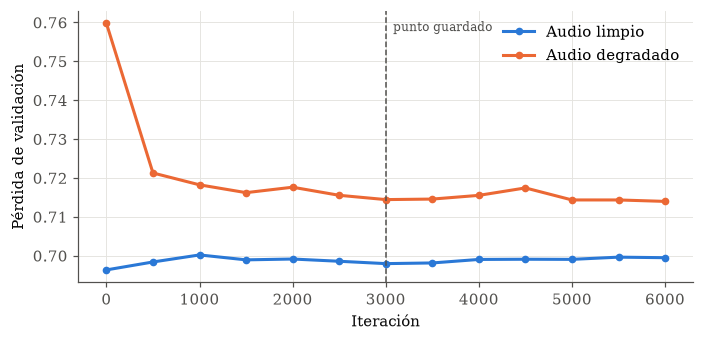

In [4]:
h = pd.DataFrame(json.loads((R / "oe2_ajuste_validacion.json").read_text()))
mejor = 3000
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(h["iteration"], h["limpio"], color=AZUL, linewidth=2, marker="o", markersize=4, label="Audio limpio")
ax.plot(h["iteration"], h["degradado"], color=NARANJA, linewidth=2, marker="o", markersize=4, label="Audio degradado")
ax.axvline(mejor, color=TINTA_2, linestyle="--", linewidth=1)
ax.text(mejor + 80, h["degradado"].max() - 0.002, "punto guardado", fontsize=8, color=TINTA_2)
ax.set_xlabel("Iteración")
ax.set_ylabel("Pérdida de validación")
ax.legend(loc="upper right")
guardar(fig, "oe2_curva_validacion")

## Cuarto objetivo: latencia

,GPU T4 (Kaggle),"Ryzen 7 5700X, 2 núcleos","Ryzen 7 5700X, 8 núcleos","Railway, 2 vCPU"
30,0.073,1.206,0.781,0.717
60,0.081,1.057,0.780,0.546
120,0.083,1.080,0.860,0.581
180,0.083,NaN,NaN,NaN
300,0.084,1.195,0.885,0.615


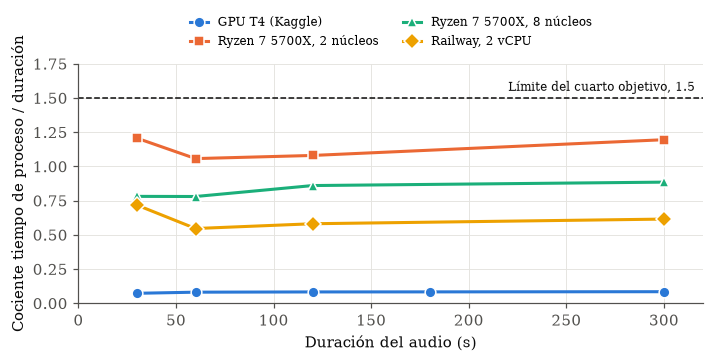

In [5]:
l = pd.read_csv(R / "oe4_latencia_e2e.csv")
cpu = pd.read_csv(R / "oe4_latencia_cpu.csv")
rw = pd.read_csv(R / "oe4_latencia_railway.csv").set_index("duracion_audio_s")["cociente_servidor"]
# Cuatro series para no pasar del cuarto color validado; los 4 núcleos quedan en la tabla
series = [("GPU T4 (Kaggle)", l.groupby("duracion_objetivo")["ratio"].max(), AZUL, "o")]
for n, color, marca in ((2, NARANJA, "s"), (8, AQUA, "^")):
    s = cpu[cpu["nucleos"] == n].set_index("duracion_audio_s")["cociente"]
    series.append((f"Ryzen 7 5700X, {n} núcleos", s, color, marca))
series.append(("Railway, 2 vCPU", rw, AMARILLO, "D"))
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for nombre, s, color, marca in series:
    ax.plot(s.index, s.values, color=color, linewidth=2, marker=marca, markersize=7, markeredgecolor="white", label=nombre)
ax.axhline(1.5, color=TINTA, linestyle="--", linewidth=1)
ax.text(316, 1.53, "Límite del cuarto objetivo, 1.5", fontsize=8, color=TINTA, va="bottom", ha="right")
ax.set_xlim(0, 320)
ax.set_ylim(0, 1.75)
ax.set_xlabel("Duración del audio (s)")
ax.set_ylabel("Cociente tiempo de proceso / duración")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncols=2, fontsize=8, handlelength=1.5)
guardar(fig, "oe4_latencia")
pd.concat({n: s for n, s, _, _ in series}, axis=1).round(3)


## Quinto objetivo: Exactitud de Símbolo Braille

Los valores vienen de `scripts/desglose_bsa.py` (Goldberg, obras externas y repertorio intermedio, grabaciones de estudio) y de `scripts/evaluar_telefono.py` (grabaciones propias con teléfono). La configuración base corta las manos en el Do central con tempo fijo; la del pipeline es la que el sistema usa por omisión.

configuracion,base,pipeline
conjunto,,
desarrollo,24.57,38.27
prueba,22.65,33.17
externo,24.79,33.63
intermedio,30.85,46.46
telefono,16.61,21.85


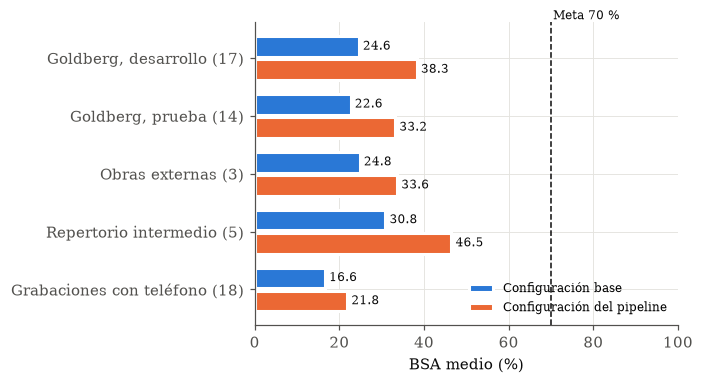

In [6]:
d = pd.read_csv(R / "oe5_desglose.csv")
t = pd.read_csv(R / "oe5_telefono.csv")
tel = t[t["fuente"] == "telefono"].assign(conjunto="telefono")
todo = pd.concat([d, tel], ignore_index=True)
nombres = {"desarrollo": "Goldberg, desarrollo", "prueba": "Goldberg, prueba", "externo": "Obras externas",
           "intermedio": "Repertorio intermedio", "telefono": "Grabaciones con teléfono"}
media = todo.groupby(["conjunto", "configuracion"])["bsa"].mean().unstack().mul(100).reindex(list(nombres))
cuenta = todo[todo["configuracion"] == "pipeline"].groupby("conjunto")["pieza"].nunique().reindex(list(nombres))
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ys = range(len(media))
alto = 0.36
for k, (conf, color, etiqueta) in enumerate((("base", AZUL, "Configuración base"), ("pipeline", NARANJA, "Configuración del pipeline"))):
    pos = [y + (k - 0.5) * (alto + 0.04) for y in ys]
    ax.barh(pos, media[conf], height=alto, color=color, edgecolor="white", linewidth=2, label=etiqueta)
    for y, v in zip(pos, media[conf]):
        ax.text(v + 1, y, f"{v:.1f}", va="center", fontsize=8, color=TINTA)
ax.axvline(70, color=TINTA, linestyle="--", linewidth=1)
ax.text(70.5, -0.62, "Meta 70 %", fontsize=8, color=TINTA, va="bottom")
ax.set_yticks(list(ys), [f"{nombres[k]} ({cuenta[k]})" for k in media.index])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("BSA medio (%)")
ax.legend(loc="lower right", fontsize=8)
guardar(fig, "oe5_bsa_por_conjunto")
media.round(2)


,f1_notas_por_compas,alturas,ritmo,bsa
conjunto,,,,
desarrollo,71.8,51.7,57.9,38.3
prueba,62.9,43.2,56.1,33.2
externo,52.7,30.9,53.7,33.6
intermedio,65.7,64.4,74.6,46.5
telefono,32.4,21.0,47.5,21.8


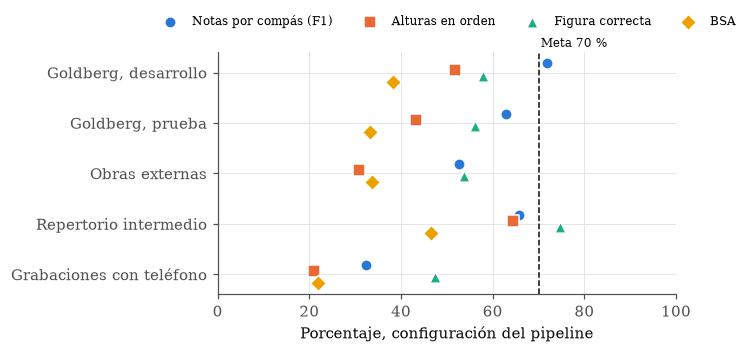

In [7]:
metricas = [("f1_notas_por_compas", "Notas por compás (F1)", AZUL, "o"), ("alturas", "Alturas en orden", NARANJA, "s"),
            ("ritmo", "Figura correcta", AQUA, "^"), ("bsa", "BSA", AMARILLO, "D")]
pip = todo[todo["configuracion"] == "pipeline"].groupby("conjunto")[[m for m, *_ in metricas]].mean().mul(100).reindex(list(nombres))
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for k, (m, etiqueta, color, marca) in enumerate(metricas):
    ax.scatter(pip[m], [y + (k - 1.5) * 0.12 for y in range(len(pip))], color=color, marker=marca, s=55,
               edgecolor="white", linewidth=1, label=etiqueta, zorder=3)
ax.axvline(70, color=TINTA, linestyle="--", linewidth=1)
ax.text(70.5, -0.45, "Meta 70 %", fontsize=8, color=TINTA, va="bottom")
ax.set_yticks(range(len(pip)), [nombres[k] for k in pip.index])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Porcentaje, configuración del pipeline")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncols=4, fontsize=8)
guardar(fig, "oe5_desglose")
pip.round(1)


fuente,estudio,telefono
pieza,,
minueto_sol,49.8,12.5
clementi_2,27.7,19.4
sonatina_sol_2,48.8,21.2
sonatina_sol_1,51.3,22.0
vals_chopin,37.0,23.6
wild_rose,16.3,28.5
fur_elise,49.0,31.5
clementi_3,25.1,39.6
clementi_1,54.7,42.4


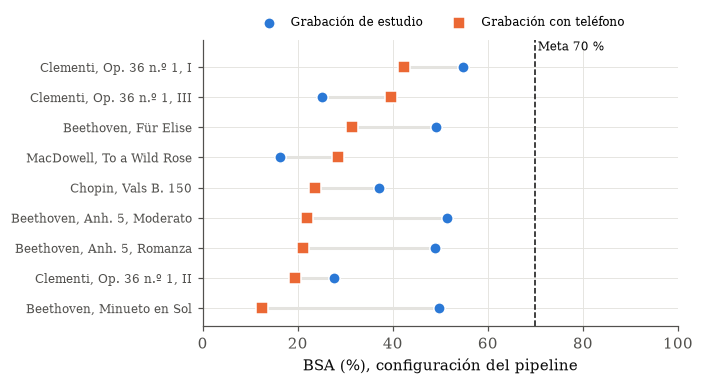

In [8]:
par = t[t["configuracion"] == "pipeline"].pivot_table(index="pieza", columns="fuente", values="bsa").mul(100).dropna()
obras = {"minueto_sol": "Beethoven, Minueto en Sol", "clementi_1": "Clementi, Op. 36 n.º 1, I", "clementi_2": "Clementi, Op. 36 n.º 1, II",
         "clementi_3": "Clementi, Op. 36 n.º 1, III", "sonatina_sol_1": "Beethoven, Anh. 5, Moderato", "sonatina_sol_2": "Beethoven, Anh. 5, Romanza",
         "wild_rose": "MacDowell, To a Wild Rose", "fur_elise": "Beethoven, Für Elise", "vals_chopin": "Chopin, Vals B. 150",
         "stravinsky_valse": "Stravinsky, Valse pour les enfants", "cinq_doigts_1": "Stravinsky, Les Cinq Doigts n.º 1",
         "cinq_doigts_2": "Stravinsky, Les Cinq Doigts n.º 2", "cinq_doigts_3": "Stravinsky, Les Cinq Doigts n.º 3",
         **{f"czerny_{k}": f"Czerny, Op. 777 n.º {k}" for k in range(1, 6)}}
par = par.sort_values("telefono")
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for y, (pieza, fila) in enumerate(par.iterrows()):
    ax.plot([fila["estudio"], fila["telefono"]], [y, y], color=REJILLA, linewidth=2, zorder=1)
ax.scatter(par["estudio"], range(len(par)), color=AZUL, marker="o", s=55, edgecolor="white", linewidth=1, label="Grabación de estudio", zorder=3)
ax.scatter(par["telefono"], range(len(par)), color=NARANJA, marker="s", s=55, edgecolor="white", linewidth=1, label="Grabación con teléfono", zorder=3)
ax.axvline(70, color=TINTA, linestyle="--", linewidth=1)
ax.text(70.5, len(par) - 0.55, "Meta 70 %", fontsize=8, color=TINTA, va="bottom")
ax.set_yticks(range(len(par)), [obras[p] for p in par.index], fontsize=8)
ax.set_xlim(0, 100)
ax.set_xlabel("BSA (%), configuración del pipeline")
ax.set_ylim(-0.6, len(par) - 0.1)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncols=2, fontsize=8)
guardar(fig, "oe5_telefono_vs_estudio")
par.round(1)


,nombre,bsa,f1_notas_por_compas,alturas,ritmo
pieza,,,,,
cinq_doigts_1,"Stravinsky, Les Cinq Doigts n.º 1",0.100,0.315,0.210,0.213
czerny_4,"Czerny, Op. 777 n.º 4",0.116,0.225,0.113,0.500
stravinsky_valse,"Stravinsky, Valse pour les enfants",0.125,0.231,0.064,0.375
czerny_5,"Czerny, Op. 777 n.º 5",0.150,0.230,0.061,0.286
czerny_3,"Czerny, Op. 777 n.º 3",0.192,0.282,0.130,0.448
cinq_doigts_3,"Stravinsky, Les Cinq Doigts n.º 3",0.201,0.303,0.156,0.611
czerny_2,"Czerny, Op. 777 n.º 2",0.207,0.348,0.182,0.544
czerny_1,"Czerny, Op. 777 n.º 1",0.207,0.221,0.159,0.559
cinq_doigts_2,"Stravinsky, Les Cinq Doigts n.º 2",0.228,0.220,0.076,0.375


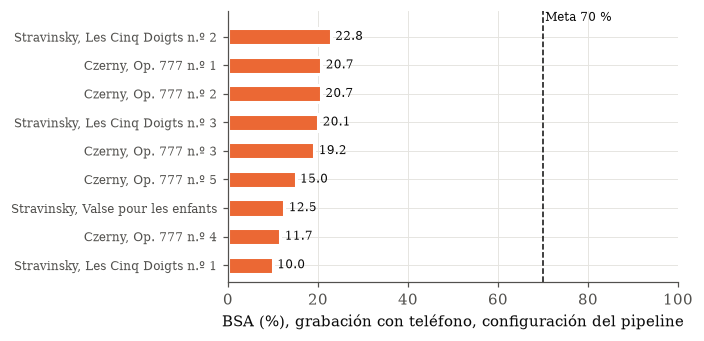

In [9]:
solo = t[(t["fuente"] == "telefono") & (t["configuracion"] == "pipeline") & ~t["pieza"].isin(par.index)].set_index("pieza")
solo = solo.assign(nombre=[obras[p] for p in solo.index]).sort_values("bsa")
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.barh(range(len(solo)), solo["bsa"] * 100, height=0.6, color=NARANJA, edgecolor="white", linewidth=2)
for y, v in enumerate(solo["bsa"] * 100):
    ax.text(v + 1, y, f"{v:.1f}", va="center", fontsize=8, color=TINTA)
ax.axvline(70, color=TINTA, linestyle="--", linewidth=1)
ax.text(70.5, len(solo) - 0.55, "Meta 70 %", fontsize=8, color=TINTA, va="bottom")
ax.set_ylim(-0.6, len(solo) - 0.1)
ax.set_yticks(range(len(solo)), solo["nombre"], fontsize=8)
ax.set_xlim(0, 100)
ax.set_xlabel("BSA (%), grabación con teléfono, configuración del pipeline")
guardar(fig, "oe5_telefono_obras_sencillas")
solo[["nombre", "bsa", "f1_notas_por_compas", "alturas", "ritmo"]].round(3)


conjunto,desarrollo,prueba,externo,intermedio
categoria,,,,
notas,38.0,31.7,37.2,52.1
octavas,52.7,46.5,53.0,53.8
alteraciones,43.2,36.2,25.4,45.4
intervalos,1.2,5.1,28.4,35.8
ligaduras,10.8,19.9,14.0,5.1
in_accords,0.1,0.4,1.0,0.0


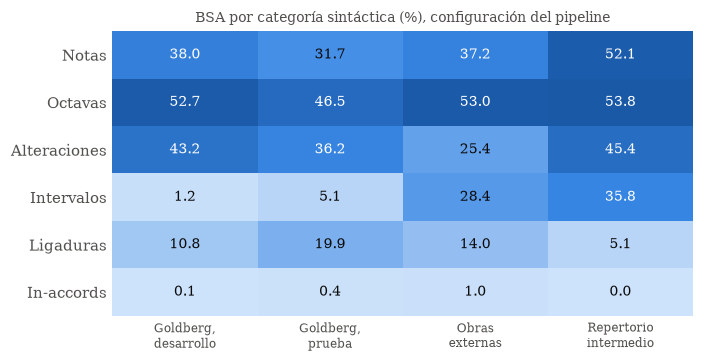

In [10]:
from matplotlib.colors import LinearSegmentedColormap
c = pd.read_csv(R / "oe5_categorias_pipeline.csv")
cats = [("notas", "Notas"), ("octavas", "Octavas"), ("alteraciones", "Alteraciones"), ("intervalos", "Intervalos"),
        ("ligaduras", "Ligaduras"), ("in_accords", "In-accords")]
conj = [("desarrollo", "Goldberg,\ndesarrollo"), ("prueba", "Goldberg,\nprueba"), ("externo", "Obras\nexternas"), ("intermedio", "Repertorio\nintermedio")]
m = c.pivot_table(index="categoria", columns="conjunto", values="bsa").reindex([k for k, _ in cats])[[k for k, _ in conj]] * 100
# Rampa secuencial azul de la paleta validada, de casi cero a máximo
azules = LinearSegmentedColormap.from_list("azul", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.imshow(m.values, cmap=azules, vmin=0, vmax=70, aspect="auto")
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        v = m.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9, color="white" if v > 35 else TINTA)
ax.set_xticks(range(len(conj)), [n for _, n in conj], fontsize=8)
ax.set_yticks(range(len(cats)), [n for _, n in cats])
ax.tick_params(length=0)
ax.grid(False)
for lado in ax.spines.values():
    lado.set_visible(False)
ax.set_title("BSA por categoría sintáctica (%), configuración del pipeline", fontsize=9, color=TINTA_2)
guardar(fig, "oe5_categorias")
m.round(1)


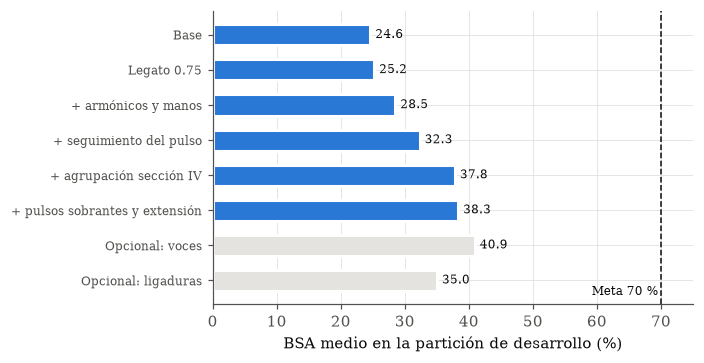

In [11]:
a = pd.read_csv(R / "oe5_ablacion_acumulada.csv")
etiquetas = ["Base", "Legato 0.75", "+ armónicos y manos", "+ seguimiento del pulso", "+ agrupación sección IV",
             "+ pulsos sobrantes y extensión", "Opcional: voces", "Opcional: ligaduras"]
fig, ax = plt.subplots(figsize=(6.5, 3.4))
colores = [AZUL if v == "si" else REJILLA for v in a["incluida_en_pipeline"]]
ax.barh(range(len(a)), a["bsa_desarrollo"], height=0.6, color=colores, edgecolor="white", linewidth=2)
for y, (v, inc) in enumerate(zip(a["bsa_desarrollo"], a["incluida_en_pipeline"])):
    ax.text(v + 0.8, y, f"{v:.1f}", va="center", fontsize=8, color=TINTA)
ax.set_yticks(range(len(a)), etiquetas, fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, 75)
ax.axvline(70, color=TINTA, linestyle="--", linewidth=1)
ax.text(69.5, len(a) - 0.5, "Meta 70 %", fontsize=8, color=TINTA, ha="right", va="bottom")
ax.set_xlabel("BSA medio en la partición de desarrollo (%)")
guardar(fig, "oe5_ablacion")


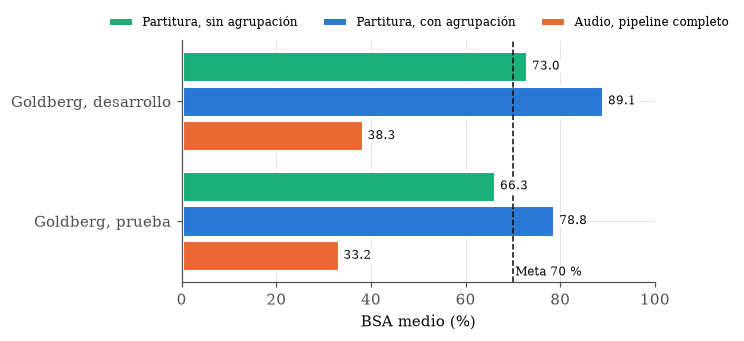

In [12]:
t = pd.read_csv(R / "oe5_techo_traductor.csv")
d = pd.read_csv(R / "oe5_desglose.csv")
audio = d[(d["configuracion"] == "pipeline") & d["conjunto"].isin(["desarrollo", "prueba"])].groupby("conjunto")["bsa"].mean() * 100
partes = ["desarrollo", "prueba"]
valores = [("Partitura, sin agrupación", t.groupby("particion")["bsa_sin_agrupacion"].mean() * 100, AQUA),
           ("Partitura, con agrupación", t.groupby("particion")["bsa_con_agrupacion"].mean() * 100, AZUL),
           ("Audio, pipeline completo", audio, NARANJA)]
fig, ax = plt.subplots(figsize=(6.5, 3.2))
alto = 0.26
for k, (nombre, serie, color) in enumerate(valores):
    pos = [y + (k - 1) * (alto + 0.03) for y in range(len(partes))]
    ax.barh(pos, serie.reindex(partes), height=alto, color=color, edgecolor="white", linewidth=2, label=nombre)
    for y, v in zip(pos, serie.reindex(partes)):
        ax.text(v + 1, y, f"{v:.1f}", va="center", fontsize=8, color=TINTA, bbox=dict(facecolor="white", edgecolor="none", pad=0.6))
ax.axvline(70, color=TINTA, linestyle="--", linewidth=1)
ax.text(70.5, 1.48, "Meta 70 %", fontsize=8, color=TINTA, va="bottom")
ax.set_yticks(range(len(partes)), ["Goldberg, desarrollo", "Goldberg, prueba"])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("BSA medio (%)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncols=3, fontsize=8)
guardar(fig, "oe5_partitura_vs_audio")


## Sexto objetivo: cliente accesible

Capturas de la aplicación publicada en una pantalla de teléfono de 390 px, tomadas con `cliente/auditoria/capturas.mjs`. La del modo tutor muestra una conversión real contra la API desplegada.


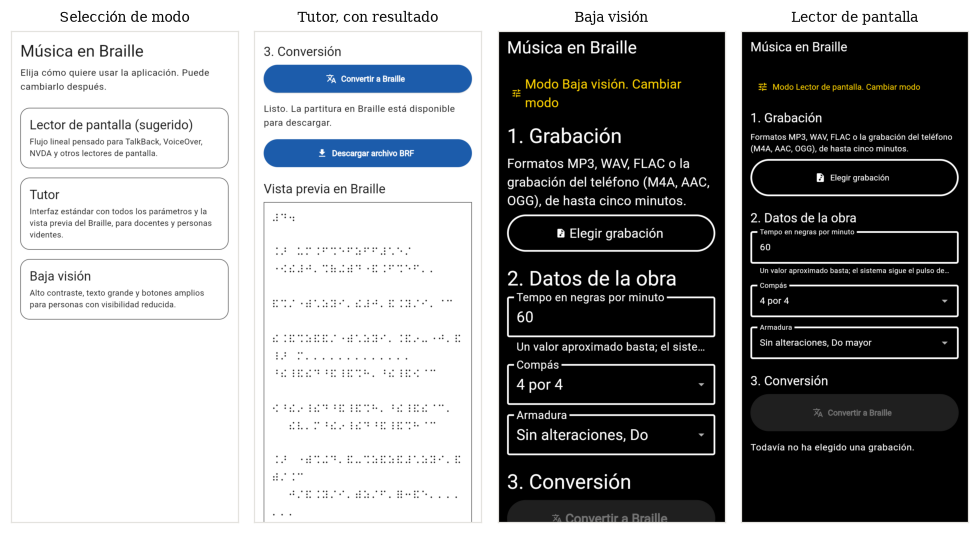

In [13]:
import matplotlib.image as mpimg
CAP = ROOT / "cliente" / "auditoria" / "capturas"
# El modo tutor se recorta desde la sección de conversión para mostrar el resultado y la vista previa
paneles = [("telefono_seleccion.png", "Selección de modo", 0), ("telefono_tutor_resultado.png", "Tutor, con resultado", 1100),
           ("telefono_bajaVision.png", "Baja visión", 0), ("telefono_nulaVision.png", "Lector de pantalla", 0)]
fig, ejes = plt.subplots(1, 4, figsize=(9, 5.2))
for ax, (archivo, titulo, desde) in zip(ejes, paneles):
    img = mpimg.imread(CAP / archivo)
    img = img[desde: desde + int(img.shape[1] * 844 / 390)]  # mismo alto de pantalla en todos los paneles
    ax.imshow(img)
    ax.set_title(titulo, fontsize=9, color=TINTA)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for lado in ax.spines.values():
        lado.set_visible(True); lado.set_color(REJILLA)
guardar(fig, "oe6_cliente")
